# Week 11 — Evaluation (lean notebook)

This notebook is the **evaluation-only** counterpart to
`11_train_and_evaluate.ipynb`. It runs the NLL ablation pipeline
(Tasks 67–69, 71–72) against every `ckpt_E*.ckpt` produced by the
training half, without any of the data-augmentation, wandb, or
training-loop machinery.

## Prerequisites

Before running this notebook, the training half of
`11_train_and_evaluate.ipynb` must already have produced:

1. `diffusion_windows_v2.parquet` in the Week-10 artifact directory
   (built by Part A / Tasks 60–63 of the training notebook).
2. At least one `ckpt_E*.ckpt` checkpoint in the same directory
   (produced by Task 66 of the training notebook).

If either is missing, run the corresponding cells in
`11_train_and_evaluate.ipynb` with `MODE = "train"` first.

> The **test split is reserved for the PI**. Every data-loading cell in
> this notebook filters to `split in {"train", "val"}`. Do not change that.


In [1]:
# Standard Week 10 setup: locate the repo, install if missing.

import os, subprocess, sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    try:
        subprocess.run(["git", "-C", repo_path, "pull"], check=True)
    except subprocess.CalledProcessError as e:
        print(f"git pull skipped: {e}")
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


There is no tracking information for the current branch.
Please specify which branch you want to merge with.
See git-pull(1) for details.

    git pull <remote> <branch>

If you wish to set tracking information for this branch you can do so with:

    git branch --set-upstream-to=origin/<branch> feature/week11



git pull skipped: Command '['git', '-C', '../../', 'pull']' returned non-zero exit status 1.
  Installing from /d0/amunozj/git_repos/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42


{'in_colab': False,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [2]:
%load_ext autoreload
%autoreload 2

import os, sys, glob, json, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import norm as sp_norm
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import repeat

import pytorch_lightning as pl
from pytorch_lightning.loggers import WandbLogger, CSVLogger
import wandb


In [3]:
# Bootstrap sys.path and locate artifacts.
import os, sys

# Several week directories ship a conditioned_infrastructure.py, but only the
# Week-10/11 copy defines find_week10_artifacts and the Extended* API — the
# Week-09 copy is an older stub. Force week_10 (the copy find_week10_artifacts
# itself resolves to, so no module eviction happens) to the FRONT of sys.path
# so the Week-09 stub can never shadow it, and add week_11 so eval mode can
# import its evaluation.py. Also drop any stale module a prior failed import
# may have cached as the Week-09 stub.
_week09_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_09"))
_week10_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_10"))
_week11_dir = os.path.abspath(os.path.join(repo_path, "weeks", "week_11"))
for _p in (_week09_dir, _week11_dir, _week10_dir):   # week_10 inserted last -> resolves first; week_09 trails so its conditioned_infrastructure stub never shadows but unconditioned_infrastructure stays importable
    if _p in sys.path:
        sys.path.remove(_p)
    sys.path.insert(0, _p)
sys.modules.pop("conditioned_infrastructure", None)

from conditioned_infrastructure import find_week10_artifacts
# parquet_v2 is built fresh in Part A every run; raw CSV is needed by the
# eval phase (Task 67 Part 1). Both are listed as required so a missing
# raw CSV fails loudly at setup time rather than at Task 67.
paths = find_week10_artifacts(extra_required=[
    "data/composite_sunspot_groups_peak_area.csv",
])
# find_week10_artifacts resolves conditioned_infrastructure to the week_10
# copy (its home, where the parquet + checkpoints live) and evicts any other
# cached copy. Repoint the *module* to the week_11 copy — that's where THIS
# notebook's API lives (E9–E11 + the cond_*_valid plumbing) — while keeping
# the week_10 artifact paths returned in `paths`.
if _week11_dir in sys.path:
    sys.path.remove(_week11_dir)
sys.path.insert(0, _week11_dir)
sys.modules.pop("conditioned_infrastructure", None)

from unconditioned_infrastructure import make_cosine_schedule
from conditioned_infrastructure import (
    ExtendedConditionalResidualDataset,
    ExtendedConditionalDiffusionLightning,
    train_experiment,
    load_trained_experiment,
    sample_conditional_extended,
    build_model,
    block_cond_concat,
    k_run_combined,
    discover_experiment_checkpoints,
)
from butterflAI_model import ButterflAIModel

import conditioned_infrastructure as _ci
print(f"using conditioned_infrastructure from: {_ci.__file__}")

_WEEK10_DIR = paths["week10_dir"]
PARQUET_V2  = os.path.join(_WEEK10_DIR, "diffusion_windows_v2.parquet")
CKPT_DIR    = _WEEK10_DIR

classical   = ButterflAIModel(paths["classical_weights"])

LAT_BINS    = np.linspace(0, 45, 16)
BIN_WIDTH   = 3.0
BIN_CENTERS = 0.5 * (LAT_BINS[:-1] + LAT_BINS[1:])

T = 200
alpha_np, sigma_np, _ = make_cosine_schedule(T=T, s=0.008)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the v1 parquet — we extend it but never modify it.
# Test split is reserved for the PI.
windows_v1 = pd.read_parquet(paths["parquet_v1"])
windows_v1 = windows_v1.loc[windows_v1["split"].isin(["train", "val"])].reset_index(drop=True)
print(f"v1 parquet (train+val only): {len(windows_v1)} rows")
print(f"  splits: {windows_v1['split'].value_counts().sort_index().to_dict()}")
print(f"  cycles: {sorted(windows_v1['cycle'].unique())}")
print(f"v2 parquet target: {PARQUET_V2}")
print(f"device           : {device}")


using conditioned_infrastructure from: /d0/amunozj/git_repos/butterflai/weeks/week_11/conditioned_infrastructure.py
v1 parquet (train+val only): 287 rows
  splits: {'train': 232, 'val': 55}
  cycles: [np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
v2 parquet target: /d0/amunozj/git_repos/butterflai/weeks/week_10/diffusion_windows_v2.parquet
device           : cuda


---
## Experiment registry

The `EXPERIMENTS` dict below must **mirror** the one in
`11_train_and_evaluate.ipynb`. Task 68's scoring loop looks up each
discovered `ckpt_E*.ckpt` here to recover its `consumed_keys`,
architecture, and other knobs. If you add a new experiment in the
training notebook, copy its entry here too — otherwise the scoring
loop will skip the checkpoint with an "unknown experiment" warning.


In [4]:
# Task 65 — experiment specs.

_BASE_TEMPLATE = {
    "arch":           "concat",
    "consumed_keys":  ["cond_base"],
    "groups":         ["base"],
    "hidden_dim":     128,
    "n_layers":       3,
    "fourier":        False,
    "cond_dropout_p": 0.0,
    "max_epochs":     20000,
    "lr":             1e-3,
    "batch_size":     64,
}

def _spec(**overrides):
    d = dict(_BASE_TEMPLATE); d.update(overrides); return d

EXPERIMENTS = {
    # # Baseline — same 4-D cond, concat arch, on the v2 parquet.
    # "E0": _spec(),

    # # Level 1 — one new cond group at a time, concat arch.
    # "E1": _spec(consumed_keys=["cond_base", "cond_cyclehemi"],
    #             groups=["base", "cyclehemi"]),
    # "E2": _spec(consumed_keys=["cond_base", "cond_opp"],
    #             groups=["base", "opp"]),
    # "E3": _spec(consumed_keys=["cond_base", "cond_traj"],
    #             groups=["base", "traj"]),

    # # Level 2 — FiLM architecture, base cond only.
    # "E4": _spec(arch="film"),

    # # Level 3 — FiLM + best L1 cond group (opp).
    # "E5": _spec(arch="film",
    #             consumed_keys=["cond_base", "cond_opp"],
    #             groups=["base", "opp"]),

    # # Level 4 — classifier-free guidance on top of L3.
    # "E6": _spec(arch="film",
    #             consumed_keys=["cond_base", "cond_opp"],
    #             groups=["base", "opp"],
    #             cond_dropout_p=0.1),

    # # Level 5 — Fourier lifting on top of L3.
    # "E7": _spec(arch="film",
    #             consumed_keys=["cond_base", "cond_opp"],
    #             groups=["base", "opp"],
    #             fourier=True),

    # # Fourier lifting on top of L3 and classifier free guidance.
    # "E8": _spec(arch="film",
    #             consumed_keys=["cond_base", "cond_opp"],
    #             groups=["base", "opp"],
    #             fourier=True,
    #             cond_dropout_p=0.1),


    # Fourier lifting on top of E3.
    "E9": _spec(arch="film",
                consumed_keys=["cond_base", "cond_traj"],
                groups=["base", "traj"],
                fourier=True),

    # # Fourier lifting on top of E3 and E2.
    # "E10": _spec(arch="film",
    #             consumed_keys=["cond_base", "cond_opp", "cond_traj"],
    #             groups=["base", "opp", "traj"],
    #             fourier=True),


    # # Fourier lifting on top of E3 plus valida window info.
    # "E11": _spec(arch="film",
    #             consumed_keys=["cond_base", "cond_traj", "cond_traj_valid"],
    #             groups=["base", "traj"],
    #             fourier=True),                                                                 
}

for name, cfg in EXPERIMENTS.items():
    print(f"{name}: arch={cfg['arch']:6s}  consumed={cfg['consumed_keys']}  "
          f"fourier={cfg['fourier']}  cond_dropout_p={cfg['cond_dropout_p']}")

E9: arch=film    consumed=['cond_base', 'cond_traj']  fourier=True  cond_dropout_p=0.0


<a id="eval-mode"></a>

---
# NLL ablations across all experiments (Tasks 67–69, 71–72)

This notebook scores every checkpoint produced by the training half
(`ckpt_E*.ckpt` in the Week-10 artifact directory) against the same
**hard-gated NLL** metric used in 10c, and adds a critical new
diagnostic: an **oracle MLP** that maps each experiment's cond vector
directly to per-bin Gaussian residual parameters. The oracle's NLL is
an *upper bound* on what any model can extract from a given cond set:

- Diffusion ≪ oracle  →  architecture is the bottleneck (try FiLM, CFG, Fourier).
- Oracle ≈ classical  →  the cond set itself doesn't help; try a different
  cond group or stop running that variant.

This is what makes the ablation scientifically honest: without an
oracle, a flat NLL across experiments could mean *either* "more cond
doesn't help" *or* "the architecture can't extract the new cond's
information" — two completely different fixes.


---
## Task 67 — Build per-window evaluation blocks

Re-window the raw CSV the same way 10c does (per-window, 6-monthly,
≥ 20 obs per window) and tag each window with its v2 parquet row's
*entire* cond superset — every group, normalized later per-experiment
using the corresponding checkpoint's `cond_<g>_means` / `cond_<g>_stds`
buffers. We work with **per-window blocks only** in 10e — that is the
granularity at which the diffusion model is native, and the granularity
where any improvement over Week 10 will be most visible.


In [5]:
# Task 67 Part 1 — per-window blocks tagged with their v2 cond superset.
from evaluation import build_eval_hemicycles

# Load v2 parquet (built by Task 63 of 11_train_and_evaluate.ipynb).
windows_v2 = pd.read_parquet(PARQUET_V2)
windows_v2 = windows_v2.loc[windows_v2["split"].isin(["train", "val"])].reset_index(drop=True)
# load_trained_experiment / score_checkpoint expect a `windows_aug` DataFrame —
# in the training notebook that's the in-memory build that gets written to the
# v2 parquet; here we read the same DataFrame back from disk, so alias it.
windows_aug = windows_v2

hemicycles, GROUP_COLS = build_eval_hemicycles(
    raw_csv_path=paths["raw_csv"],
    windows_v2=windows_v2,
    classical=classical,
    splits=("train", "val"),
)

assert len(hemicycles) > 0, "rebuild the per-window blocks before continuing"
assert all("groups_raw" in blk for hc in hemicycles for blk in hc["blocks"]), \
    "every block needs a groups_raw dict"
print(f"per-window blocks built: {sum(len(hc['blocks']) for hc in hemicycles)}")
print(f"hemicycles included    : {len(hemicycles)}")
print(f"GROUP_COLS             : {list(GROUP_COLS.keys())}")


per-window blocks built: 287
hemicycles included    : 20
GROUP_COLS             : ['base', 'cyclehemi', 'opp', 'traj', 'opp_valid', 'traj_valid']


---
## Task 67 (cont) — NLL primitives, same as 10c

These are byte-identical to the primitives in 10c. Re-stated here so
10e can be run standalone (without executing 10c first).


In [6]:
# Task 67 Part 2 — hard NLL primitives (ported from 10c) plus the
# renormalized metric and the integrity / physical-plausibility
# diagnostics added in Week 11 (all live in evaluation.py).
from evaluation import (
    hard_nll_classical,
    hard_nll_combined,
    hard_nll_combined_normalized,
    project_residuals_zero_integral,
    sample_diagnostics,
    assemble_butterfly,
    butterfly_physical_checks,
    hemispheric_symmetry,
)

# hard_nll_combined_normalized needs the latitude bin geometry. Bind it
# once so it has the (model, hcs, residuals) signature that
# k_run_combined expects and can be dropped in wherever hard_nll_combined
# is used.
def nll_norm(model, hcs, residuals_by_block):
    return hard_nll_combined_normalized(
        model, hcs, residuals_by_block, BIN_CENTERS, bin_width=BIN_WIDTH,
    )

# Zero-integral-projected variants. Demean each (15,) residual so it
# integrates to zero over the 15 uniform bins before scoring. Tests the
# hypothesis that the diffusion model is drifting away from the physical
# constraint that hist_emp - hist_par must integrate to zero, and using
# that drift to lower the un-normalized NLL.
def nll_raw_proj(model, hcs, residuals_by_block):
    return hard_nll_combined(
        model, hcs, project_residuals_zero_integral(residuals_by_block),
        bin_width=BIN_WIDTH,
    )

def nll_norm_proj(model, hcs, residuals_by_block):
    return hard_nll_combined_normalized(
        model, hcs, project_residuals_zero_integral(residuals_by_block),
        BIN_CENTERS, bin_width=BIN_WIDTH,
    )

val_hcs = [hc for hc in hemicycles if hc["split"] == "val"]
nll_cl_val, det_cl_val = hard_nll_classical(classical, val_hcs)
print(f"classical hard NLL (val): {nll_cl_val:.4f}  "
      f"(coverage {det_cl_val['coverage']:.3f})")


classical hard NLL (val): 3.2396  (coverage 1.000)


In [7]:
# Sanity check on project_residuals_zero_integral:
#   1. projection should exactly zero out the per-block integral
#   2. projection should be a constant per array (just a shift)
_rng = np.random.default_rng(0)
_synth = {("c", "h", float(i)): _rng.normal(size=15).astype(np.float32)
          for i in range(8)}
_proj = project_residuals_zero_integral(_synth)
for k, v in _synth.items():
    integral = float((_proj[k] * BIN_WIDTH).sum())
    shift    = _proj[k] - v
    assert abs(integral) < 1e-5, f"projection failed: {k} integral={integral}"
    assert np.allclose(shift, shift[0], atol=1e-6), \
        f"projection is not a pure shift for {k}"
print("project_residuals_zero_integral: integral=0 and pure-shift checks pass")


project_residuals_zero_integral: integral=0 and pure-shift checks pass


---
## Task 67 (cont) — Diagnostic oracle

For each experiment's cond set, fit a tiny MLP that maps the cond
vector directly to a 15-D Gaussian over the residual bins
(`mean`, `log_std`). The oracle's NLL is computed by sampling K
residuals from the per-block Gaussian and feeding them through
`hard_nll_combined` — the same harness used to score the diffusion.

What the oracle answers:

- **Diffusion ≪ oracle**  →  the diffusion isn't extracting the
  information that's already in the cond. Try a stronger architecture
  (FiLM, Fourier features, larger MLP).
- **Oracle ≈ classical**  →  the cond set itself doesn't carry enough
  information about the residual structure. Try a different cond
  group or stop adding to this one.

You implement this. The science (the tiny MLP, the Gaussian NLL
expression, the training loop, sampling from the predicted Gaussian)
is yours.

In [8]:
# Task 67 Part 3 — oracle MLP (imported from evaluation.py).
from evaluation import OracleMLP, gaussian_nll, fit_oracle

---
## Task 68 — Score every checkpoint

For each discovered `ckpt_E*.ckpt`:

1. Build per-experiment cond tensors for every val block by
   concatenating the right groups in `consumed_keys` order, normalized
   with the **checkpoint's own** per-group buffers (so val data uses
   train-set normalization recovered from the saved model).
2. Run K = 100 conditional samples per block using
   `sample_conditional_extended`. For E6 (CFG), repeat the sampling at
   every guidance weight in `CFG_GUIDANCE_W` and keep them as separate
   rows.
3. Fit the oracle MLP on the same (cond, standardized residual) data
   and record its val NLL as the upper bound for this cond set.
4. Plug each of the K samples into `hard_nll_combined`; report mean
   and σ over K.


In [9]:
# Task 68 — score every discovered checkpoint.

K = 100
CFG_GUIDANCE_W = [1.0, 1.5, 2.0, 3.0]


def score_checkpoint(name, cfg):
    """Score one experiment against the classical baseline and an oracle.

    Returns a list of dicts (one per guidance weight). Keys:
    {experiment, guidance_w,
     nll_mean, nll_std,                       # raw (un-normalized) hard NLL
     nll_norm_mean, nll_norm_std,             # renormalized hard NLL (leak-proof)
     nll_raw_proj_mean, nll_raw_proj_std,     # raw NLL after zero-integral projection
     nll_norm_proj_mean, nll_norm_proj_std,   # normalized NLL after zero-integral projection
     added_mass_mean, diversity_mean,         # metric-integrity diagnostics
     floor,
     oracle_nll_mean, oracle_nll_std,
     oracle_nll_norm_mean,                    # oracle floor under the normalized metric
     oracle_nll_norm_proj_mean,               # oracle floor under projected normalized metric
     oracle_gauss, coverage}.

    The raw metric is kept for the broken-vs-fixed comparison; the
    normalized metric divides each block's combined density by its total
    mass so classifier-free guidance can no longer win by piling
    un-normalized density onto the occupied bins. The _proj columns
    additionally demean each block's residual so it integrates to zero
    over the 15 bins before scoring, isolating the share of the gap that
    is explained by mass-shift "cheating" vs genuine residual mismatch.
    """
    # 1. Load checkpoint and datasets.
    lit, train_ds, val_ds, total_dim = load_trained_experiment(
        name, cfg, windows_aug, CKPT_DIR, alpha_np, sigma_np,
    )

    # 2. Build per-val-block cond tensors.
    keys, cond_tensor = block_cond_concat(val_hcs, lit, cfg, train_ds)
    N = cond_tensor.shape[0]

    # 3. Fit the oracle on the same cond set.
    #    Build (cond, r_clean) pairs from the dataset.
    train_cond = torch.stack([
        torch.cat([train_ds[i][k] for k in cfg["consumed_keys"]], dim=-1)
        for i in range(len(train_ds))
    ])
    train_r = torch.stack([train_ds[i]["r_clean"] for i in range(len(train_ds))])

    val_cond = torch.stack([
        torch.cat([val_ds[i][k] for k in cfg["consumed_keys"]], dim=-1)
        for i in range(len(val_ds))
    ])
    val_r = torch.stack([val_ds[i]["r_clean"] for i in range(len(val_ds))])

    oracle_model, oracle_gauss = fit_oracle(train_cond, train_r, val_cond, val_r)

    # Oracle samples: draw K residuals per val block from the oracle's
    # predicted Gaussian, denormalize to physical units, and score under
    # the raw, the renormalized, and the projected renormalized metric.
    oracle_model.eval()
    with torch.no_grad():
        o_mean, o_log_std = oracle_model(cond_tensor)
    o_std = torch.exp(o_log_std)
    torch.manual_seed(0)
    oracle_std_samples = (
        o_mean.unsqueeze(1)
        + o_std.unsqueeze(1) * torch.randn(N, K, 15)
    )
    bin_m = train_ds.bin_means.numpy()
    bin_s = train_ds.bin_stds.numpy()
    oracle_phys = oracle_std_samples.numpy() * bin_s + bin_m
    oracle_nlls, oracle_floors = k_run_combined(
        hard_nll_combined, classical, val_hcs, keys, oracle_phys,
    )
    oracle_nlls_n, _ = k_run_combined(
        nll_norm, classical, val_hcs, keys, oracle_phys,
    )
    oracle_nlls_np, _ = k_run_combined(
        nll_norm_proj, classical, val_hcs, keys, oracle_phys,
    )

    # 4. Sample from the diffusion model and score.
    is_cfg = cfg.get("cond_dropout_p", 0.0) > 0
    guidance_ws = CFG_GUIDANCE_W if is_cfg else [0.0]

    results = []
    for w in guidance_ws:
        cond_K = cond_tensor.repeat_interleave(K, dim=0)
        torch.manual_seed(0)
        samples_flat = sample_conditional_extended(
            lit, cond_K, guidance_w=w, device=device,
        ).cpu().numpy()
        samples_NK15 = samples_flat.reshape(N, K, 15)

        nlls, floors = k_run_combined(
            hard_nll_combined, classical, val_hcs, keys, samples_NK15,
        )
        nlls_n, _ = k_run_combined(
            nll_norm, classical, val_hcs, keys, samples_NK15,
        )
        nlls_rp, _ = k_run_combined(
            nll_raw_proj, classical, val_hcs, keys, samples_NK15,
        )
        nlls_np, _ = k_run_combined(
            nll_norm_proj, classical, val_hcs, keys, samples_NK15,
        )
        diag = sample_diagnostics(samples_NK15, bin_s, BIN_WIDTH)

        results.append({
            "experiment":                name,
            "guidance_w":                w,
            "nll_mean":                  nlls.mean(),
            "nll_std":                   nlls.std(),
            "nll_norm_mean":             nlls_n.mean(),
            "nll_norm_std":              nlls_n.std(),
            "nll_raw_proj_mean":         nlls_rp.mean(),
            "nll_raw_proj_std":          nlls_rp.std(),
            "nll_norm_proj_mean":        nlls_np.mean(),
            "nll_norm_proj_std":         nlls_np.std(),
            "added_mass_mean":           diag["added_mass"],
            "diversity_mean":            diag["diversity"],
            "floor":                     floors.mean(),
            "oracle_nll_mean":           oracle_nlls.mean(),
            "oracle_nll_std":            oracle_nlls.std(),
            "oracle_nll_norm_mean":      oracle_nlls_n.mean(),
            "oracle_nll_norm_proj_mean": oracle_nlls_np.mean(),
            "oracle_gauss":              oracle_gauss,
            "coverage":                  det_cl_val["coverage"],
        })

    return results

In [10]:
# Discover trained checkpoints and score them. Checkpoints without a
# matching EXPERIMENTS spec (e.g. a stale file from an older naming
# scheme) are skipped with a warning instead of aborting the run.
_ckpts = discover_experiment_checkpoints(_WEEK10_DIR)
_known = [name for name in _ckpts if name in EXPERIMENTS]
_unknown = [name for name in _ckpts if name not in EXPERIMENTS]
if _unknown:
    print(f"WARNING: skipping checkpoints with no EXPERIMENTS spec "
          f"(add a spec to EXPERIMENTS in both notebooks if you want to score them): {_unknown}")
print(f"scoring checkpoints: {_known}")

all_rows = []
for name in _known:
    print(f"scoring {name} ...")
    all_rows.extend(score_checkpoint(name, EXPERIMENTS[name]))

scoreboard = pd.DataFrame(all_rows)
scoreboard["classical"] = nll_cl_val
print(scoreboard.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


scoring checkpoints: ['E9']
scoring E9 ...


experiment  guidance_w  nll_mean  nll_std  nll_norm_mean  nll_norm_std  nll_raw_proj_mean  nll_raw_proj_std  nll_norm_proj_mean  nll_norm_proj_std  added_mass_mean  diversity_mean  floor  oracle_nll_mean  oracle_nll_std  oracle_nll_norm_mean  oracle_nll_norm_proj_mean  oracle_gauss  coverage  classical
        E9      0.0000    3.4121   0.0073         3.4274        0.0076             3.4439            0.0081              3.4446             0.0083           0.0170          0.0211 0.0141           3.6479          0.0954                3.6715                     3.6698       16.8786    1.0000     3.2396


---
## Task 69 — Headline plot

Bar chart, val split: classical baseline plus every experiment's NLL,
with K-σ error bars. Oracle NLL per experiment overlaid as a
horizontal dashed marker to make the "what's achievable from this cond
set" boundary visible.

For any CFG variant (`cond_dropout_p > 0`), the bar shown is the
best-NLL guidance setting; a secondary panel sweeps the guidance
weight `w` so you can see the guidance vs NLL trade.

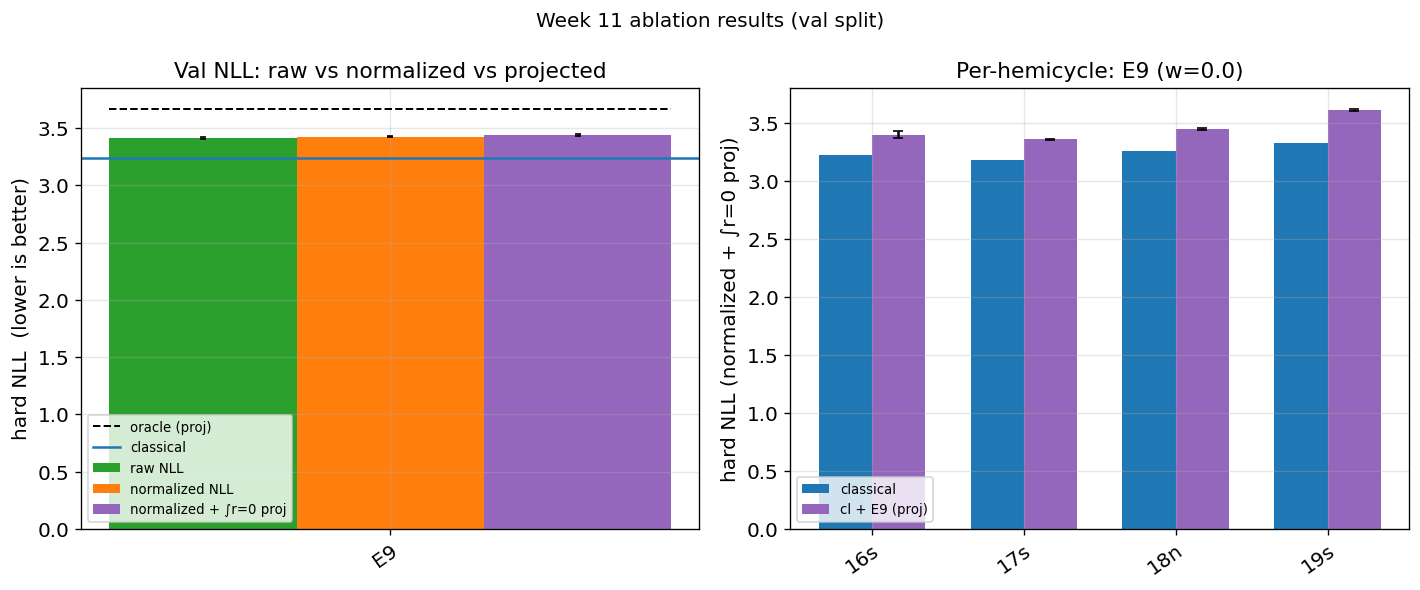

In [11]:
# Task 69 — headline plot + CFG sweep + per-hemicycle breakdown.
#
# Three metrics are now plotted side by side:
#   - raw (un-normalized) hard NLL  — gameable by mass inflation under CFG;
#   - renormalized hard NLL          — divides each block's combined density
#                                      by its total mass, closing the leak;
#   - renormalized + zero-int proj   — additionally demeans each residual so
#                                      it integrates to zero before scoring,
#                                      isolating the mass-shift cheat.
# Where raw and normalized disagree, the raw metric is lying. Where
# normalized and projected disagree, the model is also drifting away
# from the integrate-to-zero constraint that the true residual must
# satisfy (hist_emp - hist_par must integrate to 0).

# Best raw-NLL guidance_w per experiment (the setting the raw metric
# would crown). The same row carries that setting's normalized and
# projected normalized NLL.
best_idx = scoreboard.groupby("experiment")["nll_mean"].idxmin()
best_rows = scoreboard.loc[best_idx].reset_index(drop=True)

has_cfg = (scoreboard["guidance_w"] > 0.0).any()
n_panels = 3 if has_cfg else 2
fig, axes = plt.subplots(1, n_panels, figsize=(6 * n_panels, 5))

# ── Panel 1: raw vs normalized vs projected normalized val NLL ─────
ax1 = axes[0]
labels = list(best_rows["experiment"])
xr = np.arange(len(labels))
wbar = 0.27
ax1.bar(xr - wbar, best_rows["nll_mean"], wbar,
        yerr=best_rows["nll_std"], color="C2", capsize=2, label="raw NLL")
ax1.bar(xr,        best_rows["nll_norm_mean"], wbar,
        yerr=best_rows["nll_norm_std"], color="C1", capsize=2,
        label="normalized NLL")
ax1.bar(xr + wbar, best_rows["nll_norm_proj_mean"], wbar,
        yerr=best_rows["nll_norm_proj_std"], color="C4", capsize=2,
        label="normalized + ∫r=0 proj")
# Oracle floor (projected normalized) as a dashed tick spanning each
# experiment's group — same physical constraint as the model's projected
# bar, so it is the fair upper bound under this metric.
for i, (_, row) in enumerate(best_rows.iterrows()):
    ax1.plot([i - 1.5 * wbar, i + 1.5 * wbar],
             [row["oracle_nll_norm_proj_mean"]] * 2,
             "k--", lw=1.2, label="oracle (proj)" if i == 0 else None)
ax1.axhline(nll_cl_val, color="C0", lw=1.5, label="classical")
ax1.set_xticks(xr)
ax1.set_xticklabels(labels, rotation=35, ha="right", rotation_mode="anchor")
ax1.set_ylabel("hard NLL  (lower is better)")
ax1.set_title("Val NLL: raw vs normalized vs projected")
ax1.legend(fontsize=8)

# ── Panel 2: CFG guidance sweep, all three metrics ─────────────────
if has_cfg:
    ax2 = axes[1]
    cfg_rows = scoreboard[scoreboard["guidance_w"] > 0.0]
    for exp_name, grp in cfg_rows.groupby("experiment"):
        grp = grp.sort_values("guidance_w")
        line, = ax2.plot(grp["guidance_w"], grp["nll_mean"],
                         marker="o", label=f"{exp_name} raw")
        ax2.plot(grp["guidance_w"], grp["nll_norm_mean"],
                 marker="s", ls="--", color=line.get_color(),
                 label=f"{exp_name} norm")
        ax2.plot(grp["guidance_w"], grp["nll_norm_proj_mean"],
                 marker="^", ls=":", color=line.get_color(),
                 label=f"{exp_name} norm+proj")
    ax2.axhline(nll_cl_val, color="C0", ls=":", label="classical")
    ax2.set_xlabel("guidance weight $w$")
    ax2.set_ylabel("hard NLL")
    ax2.set_title("CFG sweep: raw dives, norm holds, proj is the honest floor")
    ax2.legend(fontsize=6, ncol=2)
    panel_hc = axes[2]
else:
    panel_hc = axes[1]

# ── Panel 3: per-hemicycle breakdown (projected normalized metric) ──
# Use the projected normalized NLL as the selection criterion — it
# rewards neither mass inflation nor mass shifting, so it is the most
# faithful "did this variant beat classical" test.
best_sel  = scoreboard.loc[scoreboard["nll_norm_proj_mean"].idxmin()]
best_name = best_sel["experiment"]
best_cfg  = EXPERIMENTS[best_name]
best_w    = float(best_sel["guidance_w"])

_raw_best = best_rows.loc[best_rows["nll_mean"].idxmin(), "experiment"]
if best_name != _raw_best:
    print(f"note: raw NLL favors {_raw_best} (metric exploitation under "
          f"CFG); the projected normalized metric favors {best_name} — "
          f"showcasing it.")

lit_best, train_ds_best, _, _ = load_trained_experiment(
    best_name, best_cfg, windows_aug, CKPT_DIR, alpha_np, sigma_np,
)

cycle_rows = []
for hc in val_hcs:
    nll_cl_hc, _ = hard_nll_classical(classical, [hc])
    keys_hc, cond_hc = block_cond_concat([hc], lit_best, best_cfg,
                                          train_ds_best)
    cond_K_hc = cond_hc.repeat_interleave(K, dim=0)
    torch.manual_seed(0)
    samp_hc = sample_conditional_extended(
        lit_best, cond_K_hc, guidance_w=best_w, device=device,
    ).cpu().numpy().reshape(len(keys_hc), K, 15)
    nlls_hc, _ = k_run_combined(
        nll_norm_proj, classical, [hc], keys_hc, samp_hc,
    )
    cycle_rows.append({
        "label": f"{hc['cycle']:02d}{hc['hemisphere'][0]}",
        "classical": nll_cl_hc,
        "diff_mean": nlls_hc.mean(),
        "diff_std":  nlls_hc.std(),
    })
breakdown = pd.DataFrame(cycle_rows)

x3 = np.arange(len(breakdown))
w3 = 0.35
panel_hc.bar(x3 - w3 / 2, breakdown["classical"], width=w3,
             color="C0", label="classical")
panel_hc.bar(x3 + w3 / 2, breakdown["diff_mean"],
             yerr=breakdown["diff_std"], width=w3,
             color="C4", label=f"cl + {best_name} (proj)", capsize=3)
panel_hc.set_xticks(x3)
panel_hc.set_xticklabels(breakdown["label"], rotation=35, ha="right", rotation_mode="anchor")
panel_hc.set_ylabel("hard NLL (normalized + ∫r=0 proj)")
panel_hc.set_title(f"Per-hemicycle: {best_name} (w={best_w:.1f})")
panel_hc.legend(fontsize=8)

fig.suptitle("Week 11 ablation results (val split)", fontsize=12)
fig.tight_layout()
plt.show()


---
## Task 71 — Metric integrity: why the raw NLL is gameable

The raw `hard_nll_combined` scores the *un-normalized* density
`p_cl + residual` at the observed latitudes. Classifier-free guidance
amplifies the residual (`eps = (1+w)·eps_cond − w·eps_null`), so as `w`
grows the model can pile extra density onto exactly the occupied bins
and drive the raw NLL arbitrarily negative — over-spent mass in the
empty bins is floored and never scored. `hard_nll_combined_normalized`
closes that leak by dividing each block's combined density by its total
mass.

This panel makes the exploit visible for the CFG experiments. All three
diagnostics use **robust** statistics (median, IQR) because CFG can
produce a small fraction of extreme samples that dominate mean/std:

- **added mass** = median of `Σ residual·Δlat` across blocks×K. A
  faithful residual adds ~0 net mass; values that climb with `w` are
  the leak. (The median stays near 0 even when a few samples explode —
  that the *mean* is huge while the median is small is itself a signal
  of CFG instability.)
- **diversity ratio** = median of (across-K residual IQR ÷ empirical
  IQR). Healthy = 1. Values that drift away in *either* direction are
  pathological: `<1` is mode collapse (samples too tight), `>1` is CFG
  *explosion* (a few divergent samples blow up the IQR).
- **floor fraction** = how often `p_cl + residual` went negative and
  was clamped to ``eps`` — direct evidence of an unphysical
  (negative-density) correction. Large values mean a substantial share
  of observed latitudes sit in bins where the model's "density" is not
  even non-negative.

In [12]:
# Task 71 — metric-integrity diagnostics for the CFG experiments.
cfg_rows = scoreboard[scoreboard["guidance_w"] > 0.0]
if cfg_rows.empty:
    print("No classifier-free-guidance experiments scored — nothing to diagnose.")
else:
    panels = [
        ("added_mass_mean", "added mass  (median Σ residual·Δlat)",     0.0),
        ("diversity_mean",  "diversity ratio (sample IQR / empirical)", 1.0),
        ("floor",           "floor fraction (neg-density clamps)",      0.0),
    ]
    titles = ["Mass inflation under guidance",
              "Diversity ratio drifts from healthy (=1)",
              "Negative-density clamps grow"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (col, ylabel, ref), title in zip(axes, panels, titles):
        for exp_name, grp in cfg_rows.groupby("experiment"):
            grp = grp.sort_values("guidance_w")
            ax.plot(grp["guidance_w"], grp[col], marker="o", label=exp_name)
        ax.axhline(ref, color="k", ls=":", lw=1, label="ideal")
        ax.set_xlabel("guidance weight $w$")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(fontsize=8)
    # The diversity ratio can shoot far above 1 when CFG explodes a few
    # samples, which then dominates the IQR — log scale keeps both that
    # regime and the "collapse" regime (<1) legible on one panel.
    axes[1].set_yscale("symlog", linthresh=1.0)
    fig.suptitle("Task 71 — Metric integrity diagnostics (CFG experiments)",
                 fontsize=12)
    fig.tight_layout(); plt.show()

    # One-line verdict per CFG experiment at its raw-best guidance weight.
    print("At each experiment's raw-best guidance weight:")
    for exp_name, grp in cfg_rows.groupby("experiment"):
        r = grp.loc[grp["nll_mean"].idxmin()]
        print(f"  {exp_name}: w={r['guidance_w']:.1f}  "
              f"raw NLL {r['nll_mean']:+.3f} -> normalized {r['nll_norm_mean']:+.3f}  "
              f"| added_mass {r['added_mass_mean']:+.3f}, "
              f"diversity {r['diversity_mean']:.2f}, floor {r['floor']:.3f}")


No classifier-free-guidance experiments scored — nothing to diagnose.


---
## Task 72 — Physical plausibility: assemble the butterfly diagram

NLL — even renormalized — only scores density at the latitudes where
spots were actually observed. It cannot tell you whether the *generated*
distribution is physically sensible. So we stack the showcased variant's
per-window densities into a latitude-vs-time **butterfly diagram** and
check three physical signatures:

- **Spörer's law** — the emergence-latitude centroid should drift
  *equatorward* over a hemicycle (negative slope, deg/yr).
- **Latitude bounds** — emergence should sit in the Spörer zone
  (±5–40°); mass leaking outside is unphysical.
- **Hemispheric symmetry** — where both hemispheres of a cycle are in
  the val split, their drift / band should be comparable.

We render the empirical density next to the model at low (`w=1`) and
high (`w=3`) guidance, so the over-sharpening the raw NLL rewarded shows
up as a physically wrong butterfly (a too-tight band, a flattened or
reversed drift).

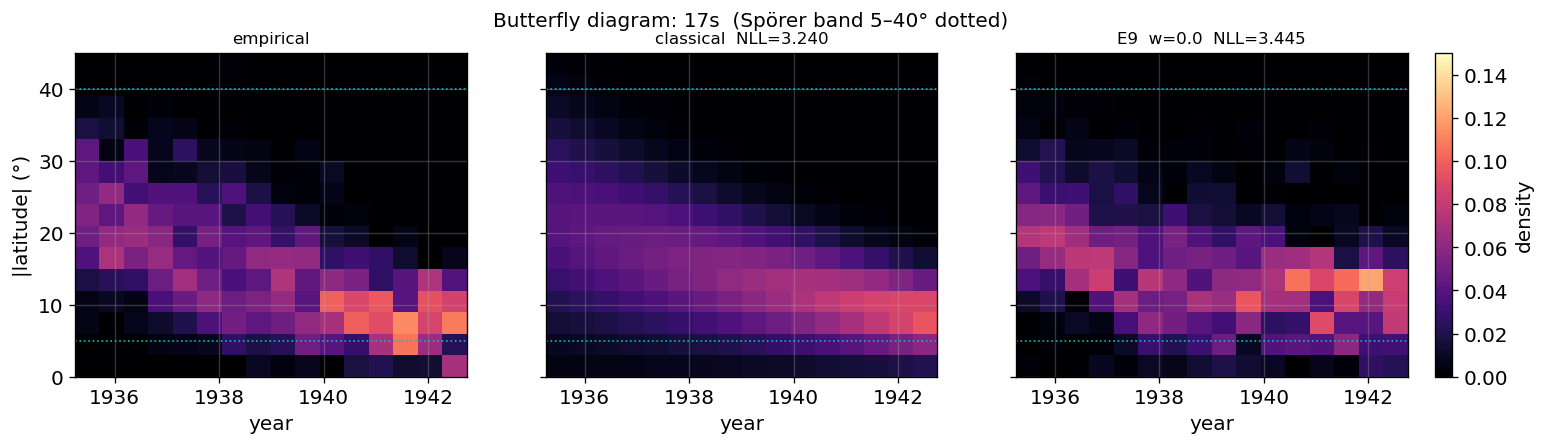


Physical checks for 17s:
       empirical: sporer_slope=-2.187 deg/yr (equatorward=True), in_band=0.881, centroid 23.7->7.7
       classical: sporer_slope=-1.722 deg/yr (equatorward=True), in_band=0.880, centroid 21.7->8.7, NLL=3.240
        E9 w=0.0: sporer_slope=-1.313 deg/yr (equatorward=True), in_band=0.897, centroid 21.3->10.3, NLL=3.445

Hemispheric symmetry: no cycle has both N and S in the val split (val is hemisphere-mixed) — per-hemicycle checks only.


In [13]:
# Task 72 — assemble per-window densities into butterfly diagrams for every
# experiment, alongside empirical + classical baselines. The classical hard
# gate is w-independent, so the set of surviving windows matches across all
# variants and the panels stay aligned.
if scoreboard.empty:
    print("no scored experiments — nothing to plot")
else:
    # Best (lowest projected-normalized NLL) row per experiment — same
    # honest-metric selection used for the per-hemicycle panel in Task 69.
    best_idx_by_exp = scoreboard.groupby("experiment")["nll_norm_proj_mean"].idxmin()
    best_by_exp = scoreboard.loc[best_idx_by_exp].set_index("experiment")

    # Showcase hemicycle: the val one with the most windows.
    hc_show  = max(val_hcs, key=lambda hc: len(hc["blocks"]))
    tag_show = f"{hc_show['cycle']:02d}{hc_show['hemisphere'][0]}"

    def _mean_resid_for(hc, lit_m, train_ds_m, cfg_m, w):
        """Mean-over-K generated residual per block: key -> (15,)."""
        keys_hc, cond_hc = block_cond_concat([hc], lit_m, cfg_m, train_ds_m)
        cond_K_hc = cond_hc.repeat_interleave(K, dim=0)
        torch.manual_seed(0)
        samp = sample_conditional_extended(
            lit_m, cond_K_hc, guidance_w=w, device=device,
        ).cpu().numpy().reshape(len(keys_hc), K, 15)
        return {key: samp[i].mean(axis=0) for i, key in enumerate(keys_hc)}

    # Generate one classical+residual butterfly per experiment.
    gen_by_exp = {}
    t_ref = None
    for exp_name in best_by_exp.index:
        row = best_by_exp.loc[exp_name]
        cfg_m = EXPERIMENTS[exp_name]
        w_m = float(row["guidance_w"])
        lit_m, train_ds_m, _, _ = load_trained_experiment(
            exp_name, cfg_m, windows_aug, CKPT_DIR, alpha_np, sigma_np,
        )
        mean_resid = _mean_resid_for(hc_show, lit_m, train_ds_m, cfg_m, w_m)
        m, t = assemble_butterfly(classical, hc_show, mean_resid, BIN_CENTERS)
        gen_by_exp[exp_name] = (m, t, w_m, float(row["nll_norm_proj_mean"]))
        if t_ref is None or t.size > t_ref.size:
            t_ref = t

    # Empirical density at the shared (gated) windows.
    _blk_by_t = {float(b["center_decimal"]): b for b in hc_show["blocks"]}
    emp_show = (np.array([np.histogram(_blk_by_t[t]["lats"], bins=LAT_BINS,
                                       density=True)[0] for t in t_ref])
                if t_ref is not None and t_ref.size else np.empty((0, 15)))

    # Classical-only butterfly: assemble with zero residuals so we reuse the
    # exact same gating + ordering as the model panels.
    zero_resid = {(hc_show["cycle"], hc_show["hemisphere"], float(t)): np.zeros(15)
                  for t in (t_ref if t_ref is not None else [])}
    cl_show, _ = assemble_butterfly(classical, hc_show, zero_resid, BIN_CENTERS)

    if t_ref is None or t_ref.size == 0:
        print(f"hemicycle {tag_show}: no windows survive the classical gate.")
    else:
        panels = [("empirical", emp_show, t_ref, None, None),
                  ("classical", cl_show, t_ref, None, nll_cl_val)]
        panels += [(name, m, t, w, nll)
                   for name, (m, t, w, nll) in gen_by_exp.items()]

        # vmax = max((m.max() for _, m, _, _, _ in panels if m.size), default=1.0)
        vmax = 0.15  # shared color scale across panels — hardcoded for legibility

        n_panels = len(panels)
        ncols = min(3, n_panels)
        nrows = int(np.ceil(n_panels / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows),
                                 sharey=True, squeeze=False)
        axes_flat = axes.flatten()

        for ax, (name, m, t, w, nll) in zip(axes_flat, panels):
            if w is None and nll is None:
                title = name
            elif w is None:
                title = f"{name}  NLL={nll:.3f}"
            else:
                title = f"{name}  w={w:.1f}  NLL={nll:.3f}"
            im = ax.imshow(m.T, origin="lower", aspect="auto", vmin=0, vmax=vmax,
                           extent=[t.min(), t.max(),
                                   LAT_BINS[0], LAT_BINS[-1]], cmap="magma")
            ax.axhline(5, color="c", ls=":", lw=1)
            ax.axhline(40, color="c", ls=":", lw=1)
            ax.set_xlabel("year")
            ax.set_title(title, fontsize=10)
        for ax in axes_flat[len(panels):]:
            ax.axis("off")
        for r in range(nrows):
            axes[r, 0].set_ylabel("|latitude| (°)")

        fig.colorbar(im, ax=axes_flat[:len(panels)].tolist(),
                     fraction=0.025, pad=0.02, label="density")
        fig.suptitle(f"Butterfly diagram: {tag_show}  "
                     f"(Spörer band 5–40° dotted)",
                     fontsize=12)
        plt.show()

        print(f"\nPhysical checks for {tag_show}:")
        c = butterfly_physical_checks(emp_show, t_ref, BIN_CENTERS)
        print(f"  {'empirical':>14}: "
              f"sporer_slope={c['sporer_slope']:+.3f} deg/yr "
              f"(equatorward={c['sporer_ok']}), "
              f"in_band={c['in_band_fraction']:.3f}, "
              f"centroid {c['centroid_start']:.1f}->{c['centroid_end']:.1f}")
        c = butterfly_physical_checks(cl_show, t_ref, BIN_CENTERS)
        print(f"  {'classical':>14}: "
              f"sporer_slope={c['sporer_slope']:+.3f} deg/yr "
              f"(equatorward={c['sporer_ok']}), "
              f"in_band={c['in_band_fraction']:.3f}, "
              f"centroid {c['centroid_start']:.1f}->{c['centroid_end']:.1f}, "
              f"NLL={nll_cl_val:.3f}")
        for name, (m, t, w, nll) in gen_by_exp.items():
            c = butterfly_physical_checks(m, t, BIN_CENTERS)
            tag = f"{name} w={w:.1f}"
            print(f"  {tag:>14}: "
                  f"sporer_slope={c['sporer_slope']:+.3f} deg/yr "
                  f"(equatorward={c['sporer_ok']}), "
                  f"in_band={c['in_band_fraction']:.3f}, "
                  f"centroid {c['centroid_start']:.1f}->{c['centroid_end']:.1f}, "
                  f"NLL={nll:.3f}")

    # Hemispheric symmetry across all val hemicycles, evaluated at each
    # experiment's best w. Same selection criterion as the per-experiment
    # panels above (lowest projected-normalized NLL).
    sym_by_exp = {}
    for exp_name in best_by_exp.index:
        row = best_by_exp.loc[exp_name]
        cfg_m = EXPERIMENTS[exp_name]
        w_m = float(row["guidance_w"])
        lit_m, train_ds_m, _, _ = load_trained_experiment(
            exp_name, cfg_m, windows_aug, CKPT_DIR, alpha_np, sigma_np,
        )
        checks_by_hc = {}
        for hc in val_hcs:
            gm, gt = assemble_butterfly(
                classical, hc,
                _mean_resid_for(hc, lit_m, train_ds_m, cfg_m, w_m),
                BIN_CENTERS,
            )
            if gm.shape[0] >= 2:
                checks_by_hc[(hc["cycle"], hc["hemisphere"])] = \
                    butterfly_physical_checks(gm, gt, BIN_CENTERS)
        sym_by_exp[exp_name] = hemispheric_symmetry(checks_by_hc)

    any_sym = any(sym for sym in sym_by_exp.values())
    if any_sym:
        print("\nHemispheric symmetry (cycles with both N and S in val):")
        for exp_name, sym in sym_by_exp.items():
            w_m = float(best_by_exp.loc[exp_name, "guidance_w"])
            if not sym:
                continue
            print(f"  {exp_name} (w={w_m:.1f}):")
            for cyc, d in sym.items():
                print(f"    cycle {cyc}: "
                      f"|slope_N - slope_S|={d['slope_diff']:.3f}, "
                      f"|in_band_N - in_band_S|={d['in_band_diff']:.3f}")
    else:
        print("\nHemispheric symmetry: no cycle has both N and S in the val "
              "split (val is hemisphere-mixed) — per-hemicycle checks only.")


---
## Handoff back to the PI

The headline numbers in `scoreboard` answer two questions:

1. **Does any variant beat the classical baseline on val?** If yes, the
   diffusion approach has earned its place in the final pipeline.
2. **Where is the bottleneck — information or architecture?** Compare
   each row's `nll_mean` to its `oracle_nll_mean`. A large gap means
   the cond set has more information than the diffusion is extracting
   (architecture-bound). A small gap with the oracle near classical
   means the cond set isn't carrying enough information — that line of
   experiments is exhausted; try a different cond group.

The PI will run the test set evaluation on whatever variant the val
results recommend.
